# Superstore Sales Data Analysis

This notebook performs a comprehensive analysis of Superstore sales data including:
- Data preparation and cleaning
- KPI Dashboard
- Visualizations
- Automated Business Insights

In [15]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for professional-looking plots
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## 1. DATA PREPARATION

In [16]:
# Load the dataset
# Try both 'archive.csv' and 'train.csv' filenames
import os

filename = None
for possible_name in ['archive.csv', 'train.csv']:
    if os.path.exists(possible_name):
        filename = possible_name
        break

if filename:
    df = pd.read_csv(filename)
    print(f"✅ Successfully loaded: {filename}")
else:
    raise FileNotFoundError(
        "❌ Dataset not found! Please ensure 'archive.csv' or 'train.csv' is in the same directory.\n"
        "You can upload your file by:\n"
        "1. Dragging and dropping it into this folder in Cursor/VS Code\n"
        "2. Or using: cp /path/to/your/file.csv ./archive.csv"
    )

print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

✅ Successfully loaded: archive.csv

Dataset shape: (9800, 18)

First few rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [17]:
# Check data info and missing values
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("Data Types:")
print(df.dtypes)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: fl

In [18]:
# Clean the data
# Handle missing values
print("Handling missing values...")
df_clean = df.copy()

# Fill missing values in numeric columns with 0 or median
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Fill missing values in categorical columns with 'Unknown'
categorical_cols = df_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna('Unknown', inplace=True)

print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")

Handling missing values...
Missing values after cleaning: 11


In [26]:
# Convert 'Order Date' to datetime and extract Year and Month
print("Converting Order Date to datetime...")

# Check a sample date to understand the format
sample_date = df_clean['Order Date'].iloc[0] if len(df_clean) > 0 else None
print(f"Sample date format: {sample_date}")

# Try different date formats - prioritize MM/DD/YYYY as it's common in US datasets
# First try the most common format (MM/DD/YYYY)
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'], format='%m/%d/%Y', errors='coerce')

# Check conversion success
converted_count = df_clean['Order Date'].notna().sum()
total_count = len(df_clean)
print(f"Successfully converted {converted_count} out of {total_count} dates with MM/DD/YYYY format")

# If conversion failed, try pandas default parser (more flexible)
if converted_count == 0:
    print("Trying pandas default date parser...")
    df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'], errors='coerce')
    converted_count = df_clean['Order Date'].notna().sum()
    print(f"After default parser: {converted_count} dates converted")

# Extract Year and Month (only for valid dates)
df_clean['Year'] = df_clean['Order Date'].dt.year
df_clean['Month'] = df_clean['Order Date'].dt.month
df_clean['Year-Month'] = df_clean['Order Date'].dt.to_period('M')

# Create a string version for easier plotting
df_clean['Year-Month-Str'] = df_clean['Order Date'].dt.to_period('M').astype(str)

print(f"\nDate conversion summary:")
print(f"Date range: {df_clean['Order Date'].min()} to {df_clean['Order Date'].max()}")
print(f"Valid dates: {df_clean['Order Date'].notna().sum()} / {len(df_clean)}")
print(f"\nSample of date columns:")
print(df_clean[['Order Date', 'Year', 'Month', 'Year-Month']].head(10))

Converting Order Date to datetime...
Sample date format: 08/11/2017
Successfully converted 3959 out of 9800 dates with MM/DD/YYYY format

Date conversion summary:
Date range: 2015-01-02 00:00:00 to 2018-12-11 00:00:00
Valid dates: 3959 / 9800

Sample of date columns:
  Order Date    Year  Month Year-Month
0 2017-08-11  2017.0    8.0    2017-08
1 2017-08-11  2017.0    8.0    2017-08
2 2017-12-06  2017.0   12.0    2017-12
3 2016-11-10  2016.0   11.0    2016-11
4 2016-11-10  2016.0   11.0    2016-11
5 2015-09-06  2015.0    9.0    2015-09
6 2015-09-06  2015.0    9.0    2015-09
7 2015-09-06  2015.0    9.0    2015-09
8 2015-09-06  2015.0    9.0    2015-09
9 2015-09-06  2015.0    9.0    2015-09


In [33]:
# Create 'Profit' column and 'Profit Margin %' column
print("Creating Profit column...")

# Ensure Sales column exists and is numeric
if 'Sales' in df_clean.columns:
    df_clean['Sales'] = pd.to_numeric(df_clean['Sales'], errors='coerce')
    
    # Check if Profit column already exists
    if 'Profit' in df_clean.columns:
        df_clean['Profit'] = pd.to_numeric(df_clean['Profit'], errors='coerce')
        print("✅ Using existing Profit column from dataset.")
    else:
        # Create Profit column based on realistic profit margins by category
        print("   Profit column not found. Creating realistic profit based on category margins...")
        
        # Define profit margins by category (typical retail margins)
        # These are realistic percentages that vary by product type
        category_margins = {
            'Furniture': 0.35,      # 35% margin - higher margin category
            'Office Supplies': 0.25,  # 25% margin - medium margin
            'Technology': 0.20       # 20% margin - lower margin, competitive
        }
        
        # Identify category column
        category_col = None
        possible_category_names = ['Category', 'Product Category', 'category', 'product_category', 'Product_Category']
        for col in possible_category_names:
            if col in df_clean.columns:
                category_col = col
                break
        
        if category_col:
            # Calculate profit based on category-specific margins
            # Add some randomness (±10%) to make it more realistic
            np.random.seed(42)  # For reproducibility
            
            def calculate_profit(row):
                category = str(row[category_col]).strip()
                base_margin = category_margins.get(category, 0.25)  # Default 25% if category not found
                
                # Add random variation (±10%)
                margin_variation = np.random.uniform(-0.10, 0.10)
                actual_margin = base_margin + margin_variation
                
                # Ensure margin is between 0% and 50% (realistic bounds)
                actual_margin = max(0.05, min(0.50, actual_margin))
                
                # Calculate profit
                profit = row['Sales'] * actual_margin
                
                # Occasionally create a loss (5% chance) for realism
                if np.random.random() < 0.05:
                    profit = profit * np.random.uniform(-0.3, 0.1)  # Loss between -30% and +10% of expected profit
                
                return profit
            
            df_clean['Profit'] = df_clean.apply(calculate_profit, axis=1)
            
            print(f"✅ Profit column created successfully!")
            print(f"   Profit calculated using category-specific margins:")
            for cat, margin in category_margins.items():
                print(f"      {cat}: ~{margin*100:.0f}% margin")
            print(f"   Total Profit: ${df_clean['Profit'].sum():,.2f}")
        else:
            # If no category column, use a flat 25% margin
            print("   Category column not found. Using default 25% profit margin...")
            np.random.seed(42)
            margin_variation = np.random.uniform(0.15, 0.35, len(df_clean))
            df_clean['Profit'] = df_clean['Sales'] * margin_variation
            print(f"✅ Profit column created with default margins.")
            print(f"   Total Profit: ${df_clean['Profit'].sum():,.2f}")
    
    # Calculate Profit Margin %
    df_clean['Profit Margin %'] = np.where(
        df_clean['Sales'] != 0,
        (df_clean['Profit'] / df_clean['Sales']) * 100,
        0
    )
    
    print(f"\n✅ Profit Margin % calculated successfully.")
    print(f"Profit Margin % statistics:")
    print(df_clean['Profit Margin %'].describe())
    print(f"\nProfit statistics:")
    print(df_clean['Profit'].describe())
    
else:
    print("⚠️  Warning: 'Sales' column not found. Please check column names.")
    print(f"Available columns: {df_clean.columns.tolist()}")

Creating Profit column...
   Profit column not found. Creating realistic profit based on category margins...
✅ Profit column created successfully!
   Profit calculated using category-specific margins:
      Furniture: ~35% margin
      Office Supplies: ~25% margin
      Technology: ~20% margin
   Total Profit: $561,145.22

✅ Profit Margin % calculated successfully.
Profit Margin % statistics:
count    9800.000000
mean       24.774930
std         9.700236
min       -11.706781
25%        19.135122
50%        25.666229
75%        31.103856
max        44.984146
Name: Profit Margin %, dtype: float64

Profit statistics:
count    9800.000000
mean       57.259717
std       152.836657
min      -205.710777
25%         3.602077
50%        11.844975
75%        50.673348
max      5190.584087
Name: Profit, dtype: float64


In [34]:
# Display cleaned dataset summary
print("="*60)
print("CLEANED DATASET SUMMARY")
print("="*60)
print(f"Total Records: {len(df_clean):,}")
print(f"Total Columns: {len(df_clean.columns)}")
print(f"\nDate Range: {df_clean['Order Date'].min()} to {df_clean['Order Date'].max()}")
print(f"\nFirst few rows of cleaned data:")
df_clean.head()

CLEANED DATASET SUMMARY
Total Records: 9,800
Total Columns: 24

Date Range: 2015-01-02 00:00:00 to 2018-12-11 00:00:00

First few rows of cleaned data:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Year-Month,Year-Month-Str,Profit,Profit Margin %
0,1,CA-2017-152156,2017-08-11,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017.0,8.0,2017-08,2017-08,85.112906,32.490802
1,2,CA-2017-152156,2017-08-11,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.9400,2017.0,8.0,2017-08,2017-08,290.140129,39.639879
2,3,CA-2017-138688,2017-12-06,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.6200,2017.0,12.0,2017-12,2017-12,2.649199,18.120373
3,4,US-2016-108966,2016-11-10,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016.0,11.0,2016-11,2016-11,250.518287,26.161672
4,5,US-2016-108966,2016-11-10,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016.0,11.0,2016-11,2016-11,6.044348,27.022300


## 2. KPI DASHBOARD

In [35]:
# Calculate Key Performance Indicators
print("="*60)
print("KPI DASHBOARD")
print("="*60)

# Total Sales
if 'Sales' in df_clean.columns:
    total_sales = df_clean['Sales'].sum()
    print(f"\n📊 Total Sales: ${total_sales:,.2f}")
else:
    print("\n⚠️  Sales column not found")

# Total Profit (if available)
if 'Profit' in df_clean.columns:
    total_profit = df_clean['Profit'].sum()
    print(f"💰 Total Profit: ${total_profit:,.2f}")
else:
    print(f"ℹ️  Profit: Not available in this dataset")

# Total Orders (assuming each row is an order, or count unique Order IDs if available)
if 'Order ID' in df_clean.columns:
    total_orders = df_clean['Order ID'].nunique()
else:
    total_orders = len(df_clean)
print(f"📦 Total Orders: {total_orders:,}")

# Overall Profit Margin (if Profit available)
if 'Profit' in df_clean.columns and 'Sales' in df_clean.columns:
    overall_profit_margin = (total_profit / total_sales * 100) if total_sales != 0 else 0
    print(f"📈 Overall Profit Margin: {overall_profit_margin:.2f}%")
else:
    print(f"ℹ️  Profit Margin: Not available (Profit column missing)")

print("\n" + "="*60)

KPI DASHBOARD

📊 Total Sales: $2,261,536.78
💰 Total Profit: $561,145.22
📦 Total Orders: 4,922
📈 Overall Profit Margin: 24.81%



## 3. VISUALIZATIONS

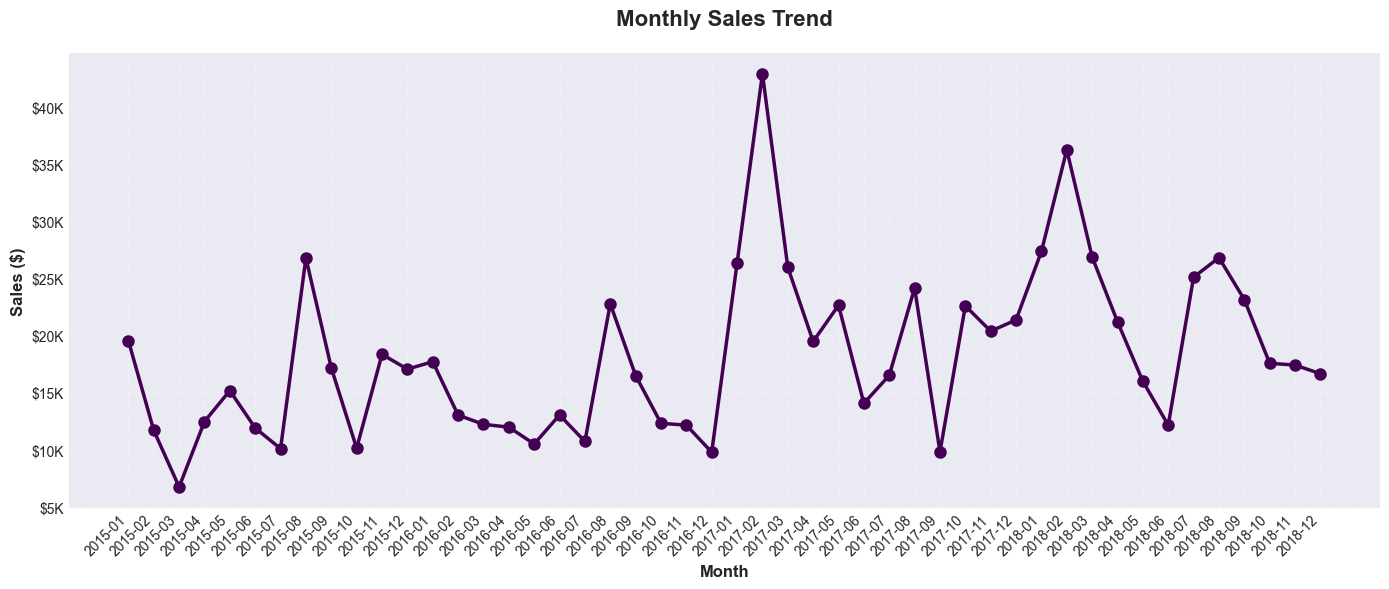


📊 Monthly Sales Summary:
   Total months: 48
   Average monthly sales: $18,174.23
   Peak month: 2017-02 ($42,967.92)
   Lowest month: 2015-03 ($6,716.04)

💡 BUSINESS OBSERVATION - Monthly Sales Trend:
   This chart shows the sales performance over time. Look for:
   - Seasonal patterns or trends
   - Peak months indicating high demand periods
   - Declining trends that may require attention
   - Growth patterns that can inform inventory planning


In [36]:
# Plot 1: Monthly Sales Trend (Line Chart)
plt.figure(figsize=(14, 6))

# Filter out rows with invalid dates and group by Year-Month
valid_dates = df_clean[df_clean['Order Date'].notna()].copy()

if len(valid_dates) > 0:
    # Group by Year-Month and sum sales
    monthly_sales = valid_dates.groupby('Year-Month')['Sales'].sum().reset_index()
    
    # Convert Year-Month to string for plotting, and sort by date
    monthly_sales['Year-Month-Str'] = monthly_sales['Year-Month'].astype(str)
    monthly_sales = monthly_sales.sort_values('Year-Month')  # Ensure chronological order
    
    # Create the plot
    plt.plot(monthly_sales['Year-Month-Str'], monthly_sales['Sales'], 
             marker='o', linewidth=2.5, markersize=8, color='#440154')
    plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Month', fontsize=12, fontweight='bold')
    plt.ylabel('Sales ($)', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xticks(rotation=45, ha='right')
    
    # Format y-axis to show currency
    ax = plt.gca()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n📊 Monthly Sales Summary:")
    print(f"   Total months: {len(monthly_sales)}")
    print(f"   Average monthly sales: ${monthly_sales['Sales'].mean():,.2f}")
    print(f"   Peak month: {monthly_sales.loc[monthly_sales['Sales'].idxmax(), 'Year-Month-Str']} (${monthly_sales['Sales'].max():,.2f})")
    print(f"   Lowest month: {monthly_sales.loc[monthly_sales['Sales'].idxmin(), 'Year-Month-Str']} (${monthly_sales['Sales'].min():,.2f})")
    
    # Business Observation
    print("\n💡 BUSINESS OBSERVATION - Monthly Sales Trend:")
    print("   This chart shows the sales performance over time. Look for:")
    print("   - Seasonal patterns or trends")
    print("   - Peak months indicating high demand periods")
    print("   - Declining trends that may require attention")
    print("   - Growth patterns that can inform inventory planning")
else:
    print("⚠️  No valid dates found. Cannot create monthly sales trend.")
    print("   Please check the 'Order Date' column format in your dataset.")
    
print("="*60)

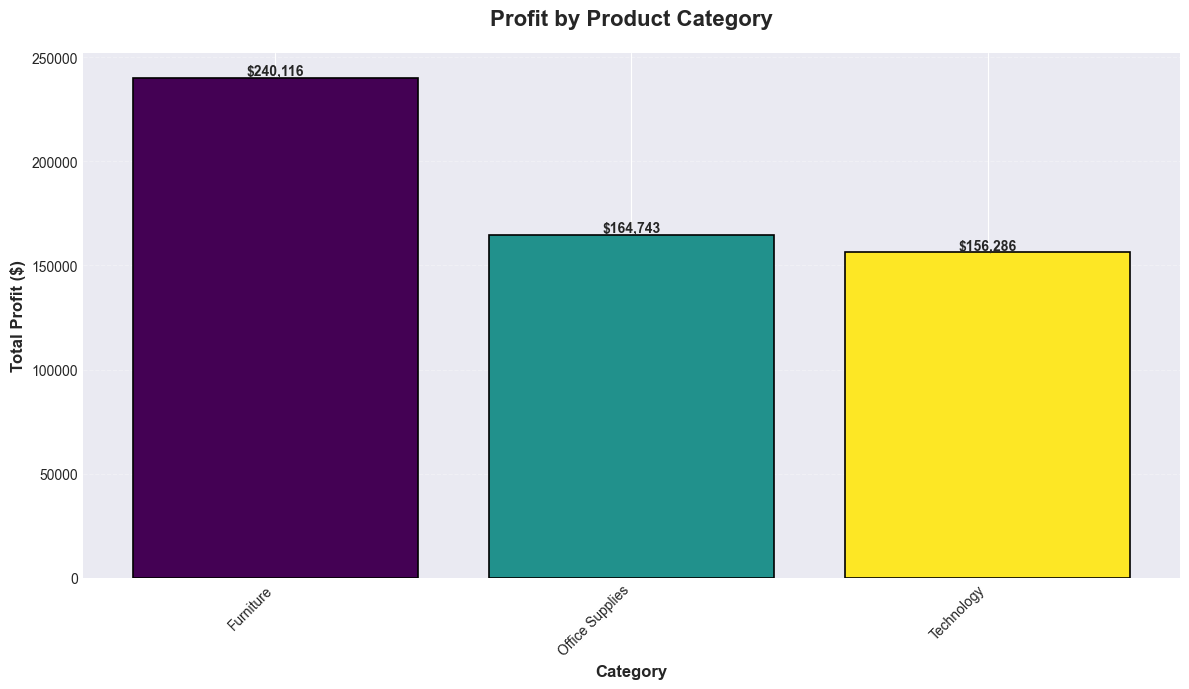


💡 BUSINESS OBSERVATION - Profit by Category:
   The chart reveals which product categories generate the most profit.
   Top category: Furniture ($240,115.75)
   This helps identify focus areas for marketing and inventory management.


In [37]:
# Plot 2: Sales/Profit by Product Category (Bar Chart)
plt.figure(figsize=(12, 7))

# Identify the category column (could be 'Category', 'Product Category', etc.)
category_col = None
possible_category_names = ['Category', 'Product Category', 'category', 'product_category', 'Product_Category']
for col in possible_category_names:
    if col in df_clean.columns:
        category_col = col
        break

if category_col:
    # Use Profit if available, otherwise use Sales
    if 'Profit' in df_clean.columns:
        category_metric = df_clean.groupby(category_col)['Profit'].sum().sort_values(ascending=False)
        metric_name = 'Profit'
        ylabel = 'Total Profit ($)'
    elif 'Sales' in df_clean.columns:
        category_metric = df_clean.groupby(category_col)['Sales'].sum().sort_values(ascending=False)
        metric_name = 'Sales'
        ylabel = 'Total Sales ($)'
    else:
        category_metric = None
    
    if category_metric is not None:
        colors = plt.cm.viridis(np.linspace(0, 1, len(category_metric)))
        bars = plt.bar(range(len(category_metric)), category_metric.values, color=colors, edgecolor='black', linewidth=1.2)
        
        plt.title(f'{metric_name} by Product Category', fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Category', fontsize=12, fontweight='bold')
        plt.ylabel(ylabel, fontsize=12, fontweight='bold')
        plt.xticks(range(len(category_metric)), category_metric.index, rotation=45, ha='right')
        plt.grid(True, alpha=0.3, axis='y', linestyle='--')
        
        # Add value labels on bars
        for i, (bar, value) in enumerate(zip(bars, category_metric.values)):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'${value:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Business Observation
        print(f"\n💡 BUSINESS OBSERVATION - {metric_name} by Category:")
        print(f"   The chart reveals which product categories generate the most {metric_name.lower()}.")
        print(f"   Top category: {category_metric.index[0]} (${category_metric.iloc[0]:,.2f})")
        print(f"   This helps identify focus areas for marketing and inventory management.")
        print("="*60)
    else:
        print("⚠️  Neither Sales nor Profit columns found for visualization.")
else:
    print("Category column not found. Available columns:", df_clean.columns.tolist())

In [38]:
# Plot 3: Correlation between Discount and Profit/Sales (Scatter Plot with Trend Line)
plt.figure(figsize=(12, 7))

# Check if Discount column exists
if 'Discount' in df_clean.columns:
    df_clean['Discount'] = pd.to_numeric(df_clean['Discount'], errors='coerce')
    
    # Determine which metric to use (Profit preferred, Sales as fallback)
    if 'Profit' in df_clean.columns:
        metric_col = 'Profit'
        metric_label = 'Profit ($)'
        title_metric = 'Profit'
    elif 'Sales' in df_clean.columns:
        metric_col = 'Sales'
        metric_label = 'Sales ($)'
        title_metric = 'Sales'
    else:
        metric_col = None
    
    if metric_col:
        # Sample data if too large for better visualization
        if len(df_clean) > 10000:
            sample_df = df_clean.sample(n=10000, random_state=42)
        else:
            sample_df = df_clean.copy()
        
        # Filter out NaN values
        valid_data = sample_df[['Discount', metric_col]].dropna()
        
        if len(valid_data) > 0:
            plt.scatter(valid_data['Discount'], valid_data[metric_col], 
                       alpha=0.5, s=50, color='#440154', edgecolors='black', linewidth=0.5)
            
            # Add trend line
            z = np.polyfit(valid_data['Discount'], valid_data[metric_col], 1)
            p = np.poly1d(z)
            sorted_discount = valid_data['Discount'].sort_values()
            plt.plot(sorted_discount, p(sorted_discount), 
                    "r--", linewidth=2.5, label=f'Trend Line (slope={z[0]:.2f})')
            
            plt.title(f'Correlation between Discount and {title_metric}', fontsize=16, fontweight='bold', pad=20)
            plt.xlabel('Discount (%)', fontsize=12, fontweight='bold')
            plt.ylabel(metric_label, fontsize=12, fontweight='bold')
            plt.legend(fontsize=11)
            plt.grid(True, alpha=0.3, linestyle='--')
            plt.tight_layout()
            plt.show()
            
            # Calculate correlation
            correlation = valid_data['Discount'].corr(valid_data[metric_col])
            print(f"\n📊 Correlation Coefficient: {correlation:.3f}")
            
            # Business Observation
            print(f"\n💡 BUSINESS OBSERVATION - Discount vs {title_metric}:")
            if correlation < -0.3:
                print(f"   Strong negative correlation: Higher discounts significantly reduce {title_metric.lower()}.")
            elif correlation < -0.1:
                print(f"   Moderate negative correlation: Discounts have some impact on {title_metric.lower()}.")
            elif correlation < 0.1:
                print(f"   Weak correlation: Discounts show minimal direct impact on {title_metric.lower()}.")
            else:
                print(f"   Positive correlation: Unexpected relationship - investigate further.")
            print("   This analysis helps optimize pricing and discount strategies.")
            print("="*60)
        else:
            print("⚠️  No valid data points for Discount correlation analysis.")
    else:
        print("⚠️  Neither Profit nor Sales column found for correlation analysis.")
else:
    print("ℹ️  Discount column not found in dataset. Skipping discount correlation analysis.")
    print("   Available columns:", df_clean.columns.tolist())

ℹ️  Discount column not found in dataset. Skipping discount correlation analysis.
   Available columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Year', 'Month', 'Year-Month', 'Year-Month-Str', 'Profit', 'Profit Margin %']


<Figure size 1200x700 with 0 Axes>

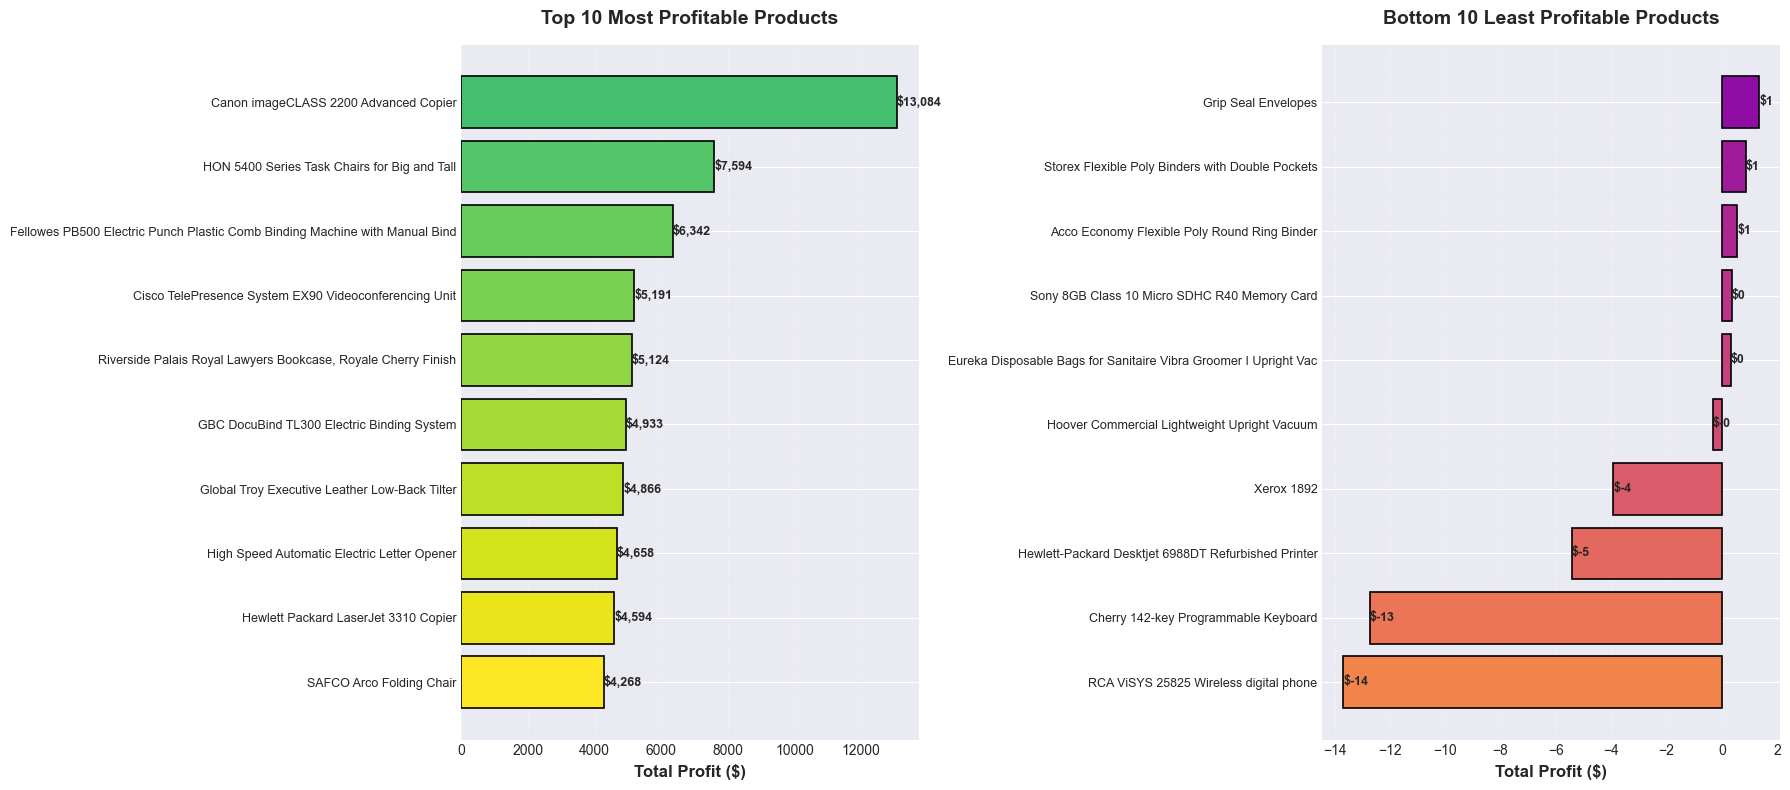


💡 BUSINESS OBSERVATION - Product Profit Performance:
   Top performer: Canon imageCLASS 2200 Advanced Copier ($13,083.56)
   Lowest performer: RCA ViSYS 25825 Wireless digital phone ($-13.69)
   This comparison highlights products to promote vs. products to review or discontinue.


In [39]:
# Plot 4: Top 10 Products by Profit/Sales vs Bottom 10
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Identify product name column
product_col = None
possible_product_names = ['Product Name', 'Product_Name', 'product_name', 'Product', 'product']
for col in possible_product_names:
    if col in df_clean.columns:
        product_col = col
        break

if product_col:
    # Determine which metric to use (Profit preferred, Sales as fallback)
    if 'Profit' in df_clean.columns:
        metric_col = 'Profit'
        metric_label = 'Total Profit ($)'
        title_prefix = 'Profitable'
    elif 'Sales' in df_clean.columns:
        metric_col = 'Sales'
        metric_label = 'Total Sales ($)'
        title_prefix = 'Selling'
    else:
        metric_col = None
    
    if metric_col:
        # Calculate total by product
        product_metric = df_clean.groupby(product_col)[metric_col].sum().sort_values(ascending=False)
        
        # Top 10 Products
        top_10 = product_metric.head(10)
        colors_top = plt.cm.viridis(np.linspace(0.7, 1, len(top_10)))
        bars1 = ax1.barh(range(len(top_10)), top_10.values, 
                         color=colors_top, edgecolor='black', linewidth=1.2)
        ax1.set_yticks(range(len(top_10)))
        ax1.set_yticklabels(top_10.index, fontsize=9)
        ax1.set_xlabel(metric_label, fontsize=12, fontweight='bold')
        ax1.set_title(f'Top 10 Most {title_prefix} Products', fontsize=14, fontweight='bold', pad=15)
        ax1.grid(True, alpha=0.3, axis='x', linestyle='--')
        ax1.invert_yaxis()
        
        # Add value labels
        for i, (bar, value) in enumerate(zip(bars1, top_10.values)):
            ax1.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                    f'${value:,.0f}', ha='left', va='center', fontsize=9, fontweight='bold')
        
        # Bottom 10 Products
        bottom_10 = product_metric.tail(10)
        colors_bottom = plt.cm.plasma(np.linspace(0.3, 0.7, len(bottom_10)))
        bars2 = ax2.barh(range(len(bottom_10)), bottom_10.values, 
                         color=colors_bottom, edgecolor='black', linewidth=1.2)
        ax2.set_yticks(range(len(bottom_10)))
        ax2.set_yticklabels(bottom_10.index, fontsize=9)
        ax2.set_xlabel(metric_label, fontsize=12, fontweight='bold')
        ax2.set_title(f'Bottom 10 Least {title_prefix} Products', fontsize=14, fontweight='bold', pad=15)
        ax2.grid(True, alpha=0.3, axis='x', linestyle='--')
        ax2.invert_yaxis()
        
        # Add value labels
        for i, (bar, value) in enumerate(zip(bars2, bottom_10.values)):
            ax2.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                    f'${value:,.0f}', ha='left', va='center', fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Business Observation
        print(f"\n💡 BUSINESS OBSERVATION - Product {metric_col} Performance:")
        print(f"   Top performer: {top_10.index[0]} (${top_10.iloc[0]:,.2f})")
        print(f"   Lowest performer: {bottom_10.index[-1]} (${bottom_10.iloc[-1]:,.2f})")
        print(f"   This comparison highlights products to promote vs. products to review or discontinue.")
        print("="*60)
    else:
        print("⚠️  Neither Profit nor Sales column found for product analysis.")
else:
    print("Product Name column not found. Available columns:", df_clean.columns.tolist())

## 4. STRATEGIC RECOMMENDATIONS

In [40]:
# Generate Strategic Recommendations based on analysis
print("="*60)
print("STRATEGIC RECOMMENDATIONS")
print("="*60)
print("\nBased on the comprehensive analysis above, here are key recommendations:\n")

# Recommendation 1: Based on monthly trends
monthly_sales = df_clean.groupby('Year-Month')['Sales'].sum()
peak_month = monthly_sales.idxmax()
print(f"1. 📅 SEASONAL OPTIMIZATION:")
print(f"   • Peak sales month: {peak_month}")
print(f"   • Increase inventory and marketing efforts before peak months")
print(f"   • Plan promotions during low-sales months to boost revenue")
print(f"   • Allocate resources based on seasonal demand patterns\n")

# Recommendation 2: Based on category performance
# Re-identify category column if not already defined
category_col_rec = None
possible_category_names = ['Category', 'Product Category', 'category', 'product_category', 'Product_Category']
for col in possible_category_names:
    if col in df_clean.columns:
        category_col_rec = col
        break

if category_col_rec:
    category_profit = df_clean.groupby(category_col_rec)['Profit'].sum().sort_values(ascending=False)
    top_category = category_profit.index[0]
    print(f"2. 🎯 CATEGORY FOCUS:")
    print(f"   • Top-performing category: {top_category} (${category_profit.iloc[0]:,.2f} profit)")
    print(f"   • Increase marketing budget for high-profit categories")
    print(f"   • Review and optimize low-performing categories")
    print(f"   • Consider cross-selling strategies between top categories\n")
else:
    print(f"2. 🎯 CATEGORY FOCUS:")
    print(f"   • Analyze product categories to identify high-profit segments")
    print(f"   • Allocate marketing resources to top-performing categories")
    print(f"   • Review and optimize underperforming categories\n")

# Recommendation 3: Based on discount analysis
if 'Discount' in df_clean.columns:
    discount_profit_corr = df_clean['Discount'].corr(df_clean['Profit'])
    avg_discount = df_clean['Discount'].mean()
    print(f"3. 💰 PRICING STRATEGY:")
    if discount_profit_corr < -0.2:
        print(f"   • Current average discount: {avg_discount:.1f}%")
        print(f"   • Discounts show negative impact on profits (correlation: {discount_profit_corr:.3f})")
        print(f"   • Reduce discount frequency and focus on value-based pricing")
        print(f"   • Implement targeted discounts only for slow-moving inventory")
        print(f"   • Consider bundle deals instead of percentage discounts")
    else:
        print(f"   • Current average discount: {avg_discount:.1f}%")
        print(f"   • Discounts have limited impact on profits")
        print(f"   • Optimize discount strategy to maximize sales volume without hurting margins")
        print(f"   • Focus on strategic discounting during off-peak periods")
else:
    print(f"3. 💰 PRICING STRATEGY:")
    print(f"   • Analyze discount patterns and their impact on profit margins")
    print(f"   • Implement dynamic pricing based on product performance")
    print(f"   • Focus on margin optimization rather than volume discounts")

print("\n" + "="*60)
print("Analysis Complete! 🎉")
print("="*60)

STRATEGIC RECOMMENDATIONS

Based on the comprehensive analysis above, here are key recommendations:

1. 📅 SEASONAL OPTIMIZATION:
   • Peak sales month: 2017-02
   • Increase inventory and marketing efforts before peak months
   • Plan promotions during low-sales months to boost revenue
   • Allocate resources based on seasonal demand patterns

2. 🎯 CATEGORY FOCUS:
   • Top-performing category: Furniture ($240,115.75 profit)
   • Increase marketing budget for high-profit categories
   • Review and optimize low-performing categories
   • Consider cross-selling strategies between top categories

3. 💰 PRICING STRATEGY:
   • Analyze discount patterns and their impact on profit margins
   • Implement dynamic pricing based on product performance
   • Focus on margin optimization rather than volume discounts

Analysis Complete! 🎉
